This script is to construct a simple underground model, that contains a mesh, with artificial dataset of a ground property (e.g. stiffness) and scale of fluctuation. 

In [1]:
import os
from pathlib import Path
import pyvista as pv
import numpy as np
import vtk
from vtk.util.numpy_support import numpy_to_vtk
import ogs as ogs
import generate_random_field

In [2]:
out_dir = Path(os.environ.get("OGS_TESTRUNNER_OUT_DIR", "_out"))
if not out_dir.exists():
    out_dir.mkdir(parents=True)

os.chdir(out_dir)

In [ ]:
import Mesh_settings

# ---- Parameters ----
# Define parameters for the mesh generation
lx, ly,lz= Mesh_settings.lx,  Mesh_settings.ly, Mesh_settings.lz
ex, ey,ez = Mesh_settings.ex, Mesh_settings.ey, Mesh_settings.ez
resolution = lz/ez
nx, ny, nz = ex+1,ey+1, ez+1
layers = Mesh_settings.layers
initial_GWT = -Mesh_settings.initial_GWT_depth 
duration = Mesh_settings.duration
layers = Mesh_settings.layers

scales = (22, 1.17)  # Correlational length (horizontal, vertical)
acf_type="exponential" 
distribution="lognormal"  
cov = 0.3
g = -9.81  # gravity

file = 'empty_mesh.vtu'

In [ ]:
if ey > 1:  # 3D case
    ogs.cli.generateStructuredMesh(o= file ,e='hex',lx=lx,ly=ly,lz=lz, nx=ex,ny=ey,nz=ez,oz=-lz)

else:  # 2D case
    ogs.cli.generateStructuredMesh(o= file ,e='quad',lx=lx,ly=lz, nx=ex,ny=ez,oy=-lz)

In [ ]:
ogs.cli.identifySubdomains (m = file, s = '1e-6', f= file)

0

In [6]:
# pyvista settings
pv.set_plot_theme("document")
pv.set_jupyter_backend("static")

In [ ]:
# Get the structure of the empty mesh as a backbone
mesh = pv.read(file) 
reader = vtk.vtkXMLUnstructuredGridReader()
reader.SetFileName(file) 
reader.Update()  # Needed because of GetScalarRange
reader_data = reader.GetOutput()

FileNotFoundError: File (c:\Users\glori\OneDrive\Onenote\Python Scripts\model\empty_mesh.vtu) not found

In [ ]:
# ---- Generate Random Field ----
# Generate a random field with increasing stiffness and variance with depth
trend = generate_random_field.formula_derived_layer(lz, nz, layers, initial_GWT)

if ex ==1 and ey==1: # 1D case
    field = generate_random_field.stepwise_cmd_1d_random_field(
        nz, lz,
        scales[1], # Correlation scales
        cov,
        trend,  # Stiffness mean trend
        acf_type = acf_type,  # Type of autocorrelation function
        distribution = distribution  # e.g. Lognormal distribution for stiffness
    )

    stiff_field = generate_random_field.convert_to_element_field_1d(field, ez)
    stiff_field=np.flip(stiff_field, axis=0)

else:
    field = generate_random_field.stepwise_cmd_3d_random_field(   
        nx, ny, nz,  # Dimensions of the field
        lx, ly, lz,
        (scales[0], scales[0], scales[1]),  # Correlation scales
        cov,
        trend,  # Stiffness mean trend
        acf_type = acf_type,  # Type of autocorrelation function
        distribution = distribution  # e.g. Lognormal distribution for stiffness
    ) #3D case
    
    # ---- Convert to Element Field ----
    # Convert node-based field to element-based field (averaged values for visualization)
    element_field = generate_random_field.convert_to_element_field(field, ex, ey, ez) # to convert node-based RF to element-based RF
    #element_field = field[1:,1:,1:] # without conversion
    
    if ey==1:
        stiff_field = element_field[:, 0, :] # Extract the 2D stiffness field for plotting, which is a plane of the 3D random field model.
        stiff_field=np.flip(stiff_field, axis=1)
    else:
        stiff_field = element_field[:, :, :]  
        stiff_field=np.flip(stiff_field, axis=2)

c:\Users\glori\OneDrive\Onenote\Python Scripts\model\generate_random_field.py:135: RuntimeWarning: divide by zero encountered in log
  mean_z = np.log(stiffness_modulus_z) - 0.5 * np.log(1 + cov**2)


In [ ]:
# ---- Add parameters to the empty mesh ----

stiffness_1D_array =  stiff_field.flatten('F')
stiffness_vtk = numpy_to_vtk(stiffness_1D_array)
stiffness_vtk.SetName('Stiffness')
reader_data.GetCellData().AddArray(stiffness_vtk)

dz = lz / ez
depths = np.linspace(-lz + dz/2, -dz/2, ez)  # cell centers

# Initialize arrays
density_1D_array = np.zeros(ez)
nu_1D_array = np.zeros(ez)
phi_1D_array = np.zeros(ez)
initial_pore_pressure = np.zeros(ez)
initial_stress_xx_1D_array = np.zeros(ez)
initial_stress_yy_1D_array = np.zeros(ez)

# Loop through all depths (element centers)
for i, depth in enumerate(depths):
    sigma_yy = 0
    nu_at_depth = 0
    density_at_depth = 0
    phi_at_depth = 0

    for z_start, z_end, v, w, density, nu, phi in layers:
        layer_top = -z_start
        layer_bottom = -z_end

        if layer_bottom >= depth:
            thickness = layer_top - layer_bottom
            if layer_top >= initial_GWT and layer_bottom >= initial_GWT:
                gamma = (1 - phi) * density * g
            elif layer_top < initial_GWT and layer_bottom < initial_GWT:
                gamma = ((1 - phi) * density + phi * 1000) * g
            else:
                above_thickness = layer_top - initial_GWT
                below_thickness = initial_GWT - layer_bottom
                gamma_above = (1 - phi) * density * g
                gamma_below = ((1 - phi) * density + phi * 1000) * g
                sigma_yy += gamma_above * above_thickness
                sigma_yy += gamma_below * below_thickness
                continue
            sigma_yy += gamma * thickness

        elif layer_bottom < depth <= layer_top:
            thickness = layer_top - depth
            nu_at_depth = nu
            density_at_depth = density
            phi_at_depth = phi
            if layer_top >= initial_GWT and depth >= initial_GWT:
                gamma = (1 - phi) * density * g
            elif layer_top < initial_GWT and depth < initial_GWT:
                gamma = ((1 - phi) * density + phi * 1000) * g
            else:
                above_thickness = layer_top - initial_GWT
                below_thickness = initial_GWT - depth
                gamma_above = (1 - phi) * density * g
                gamma_below = ((1 - phi) * density + phi * 1000) * g
                sigma_yy += gamma_above * above_thickness
                sigma_yy += gamma_below * below_thickness
                thickness = 0
            if thickness > 0:
                sigma_yy += gamma * thickness

    # Store material properties
    density_1D_array[i] = density_at_depth
    nu_1D_array[i] = nu_at_depth
    phi_1D_array[i] = phi_at_depth

    # Compute stress components
    sigma_xx = nu_at_depth / (1 - nu_at_depth) * sigma_yy
    initial_stress_yy_1D_array[i] = sigma_yy
    initial_stress_xx_1D_array[i] = sigma_xx

    # Compute pore pressure
    if depth < initial_GWT:
        initial_pore_pressure[i] = 1000 * (initial_GWT - depth) * g
    else:
        initial_pore_pressure[i] = 0.0

# Flatten and repeat arrays to match mesh shape
n_cells = ex * ey * ez

density_1D_array = np.repeat(density_1D_array, ex * ey)
nu_1D_array = np.repeat(nu_1D_array, ex * ey)
phi_1D_array = np.repeat(phi_1D_array, ex * ey)
initial_pore_pressure = np.repeat(initial_pore_pressure, ex * ey)
initial_stress_xx_1D_array = np.repeat(initial_stress_xx_1D_array, ex * ey)
initial_stress_yy_1D_array = np.repeat(initial_stress_yy_1D_array, ex * ey)

# Combine stress components
if ey == 1:
    initial_stress_1D_array = np.column_stack((
        initial_stress_xx_1D_array,
        initial_stress_yy_1D_array,
        initial_stress_xx_1D_array,
        np.zeros_like(initial_stress_xx_1D_array)
    ))
else:
    initial_stress_1D_array = np.column_stack((
        initial_stress_xx_1D_array,
        initial_stress_xx_1D_array,
        initial_stress_yy_1D_array,
        np.zeros_like(initial_stress_xx_1D_array),
        np.zeros_like(initial_stress_xx_1D_array),
        np.zeros_like(initial_stress_xx_1D_array)
    ))

In [ ]:
density_vtk = numpy_to_vtk(density_1D_array)
nu_vtk = numpy_to_vtk(nu_1D_array)
phi_vtk = numpy_to_vtk(phi_1D_array)
initial_stress_vtk = numpy_to_vtk(initial_stress_1D_array)
#initial_pore_pressure_vtk = numpy_to_vtk(initial_pore_pressure)

density_vtk.SetName('Density')
nu_vtk.SetName('nu')
phi_vtk.SetName('Porosity')
initial_stress_vtk.SetName('initial_stress')
#initial_pore_pressure_vtk.SetName('initial_pore_pressure')


reader_data.GetCellData().AddArray(density_vtk)
reader_data.GetCellData().AddArray(nu_vtk)
reader_data.GetCellData().AddArray(phi_vtk)
reader_data.GetCellData().AddArray(initial_stress_vtk)
#reader_data.GetCellData().AddArray(initial_pore_pressure_vtk)

# write all parameters to the vtu
writer = vtk.vtkXMLUnstructuredGridWriter()
writer.SetInputData(reader_data)
writer.SetFileName("domain_with_stiffness.vtu")
writer.Write()

1

We read and plot the new mesh file. 

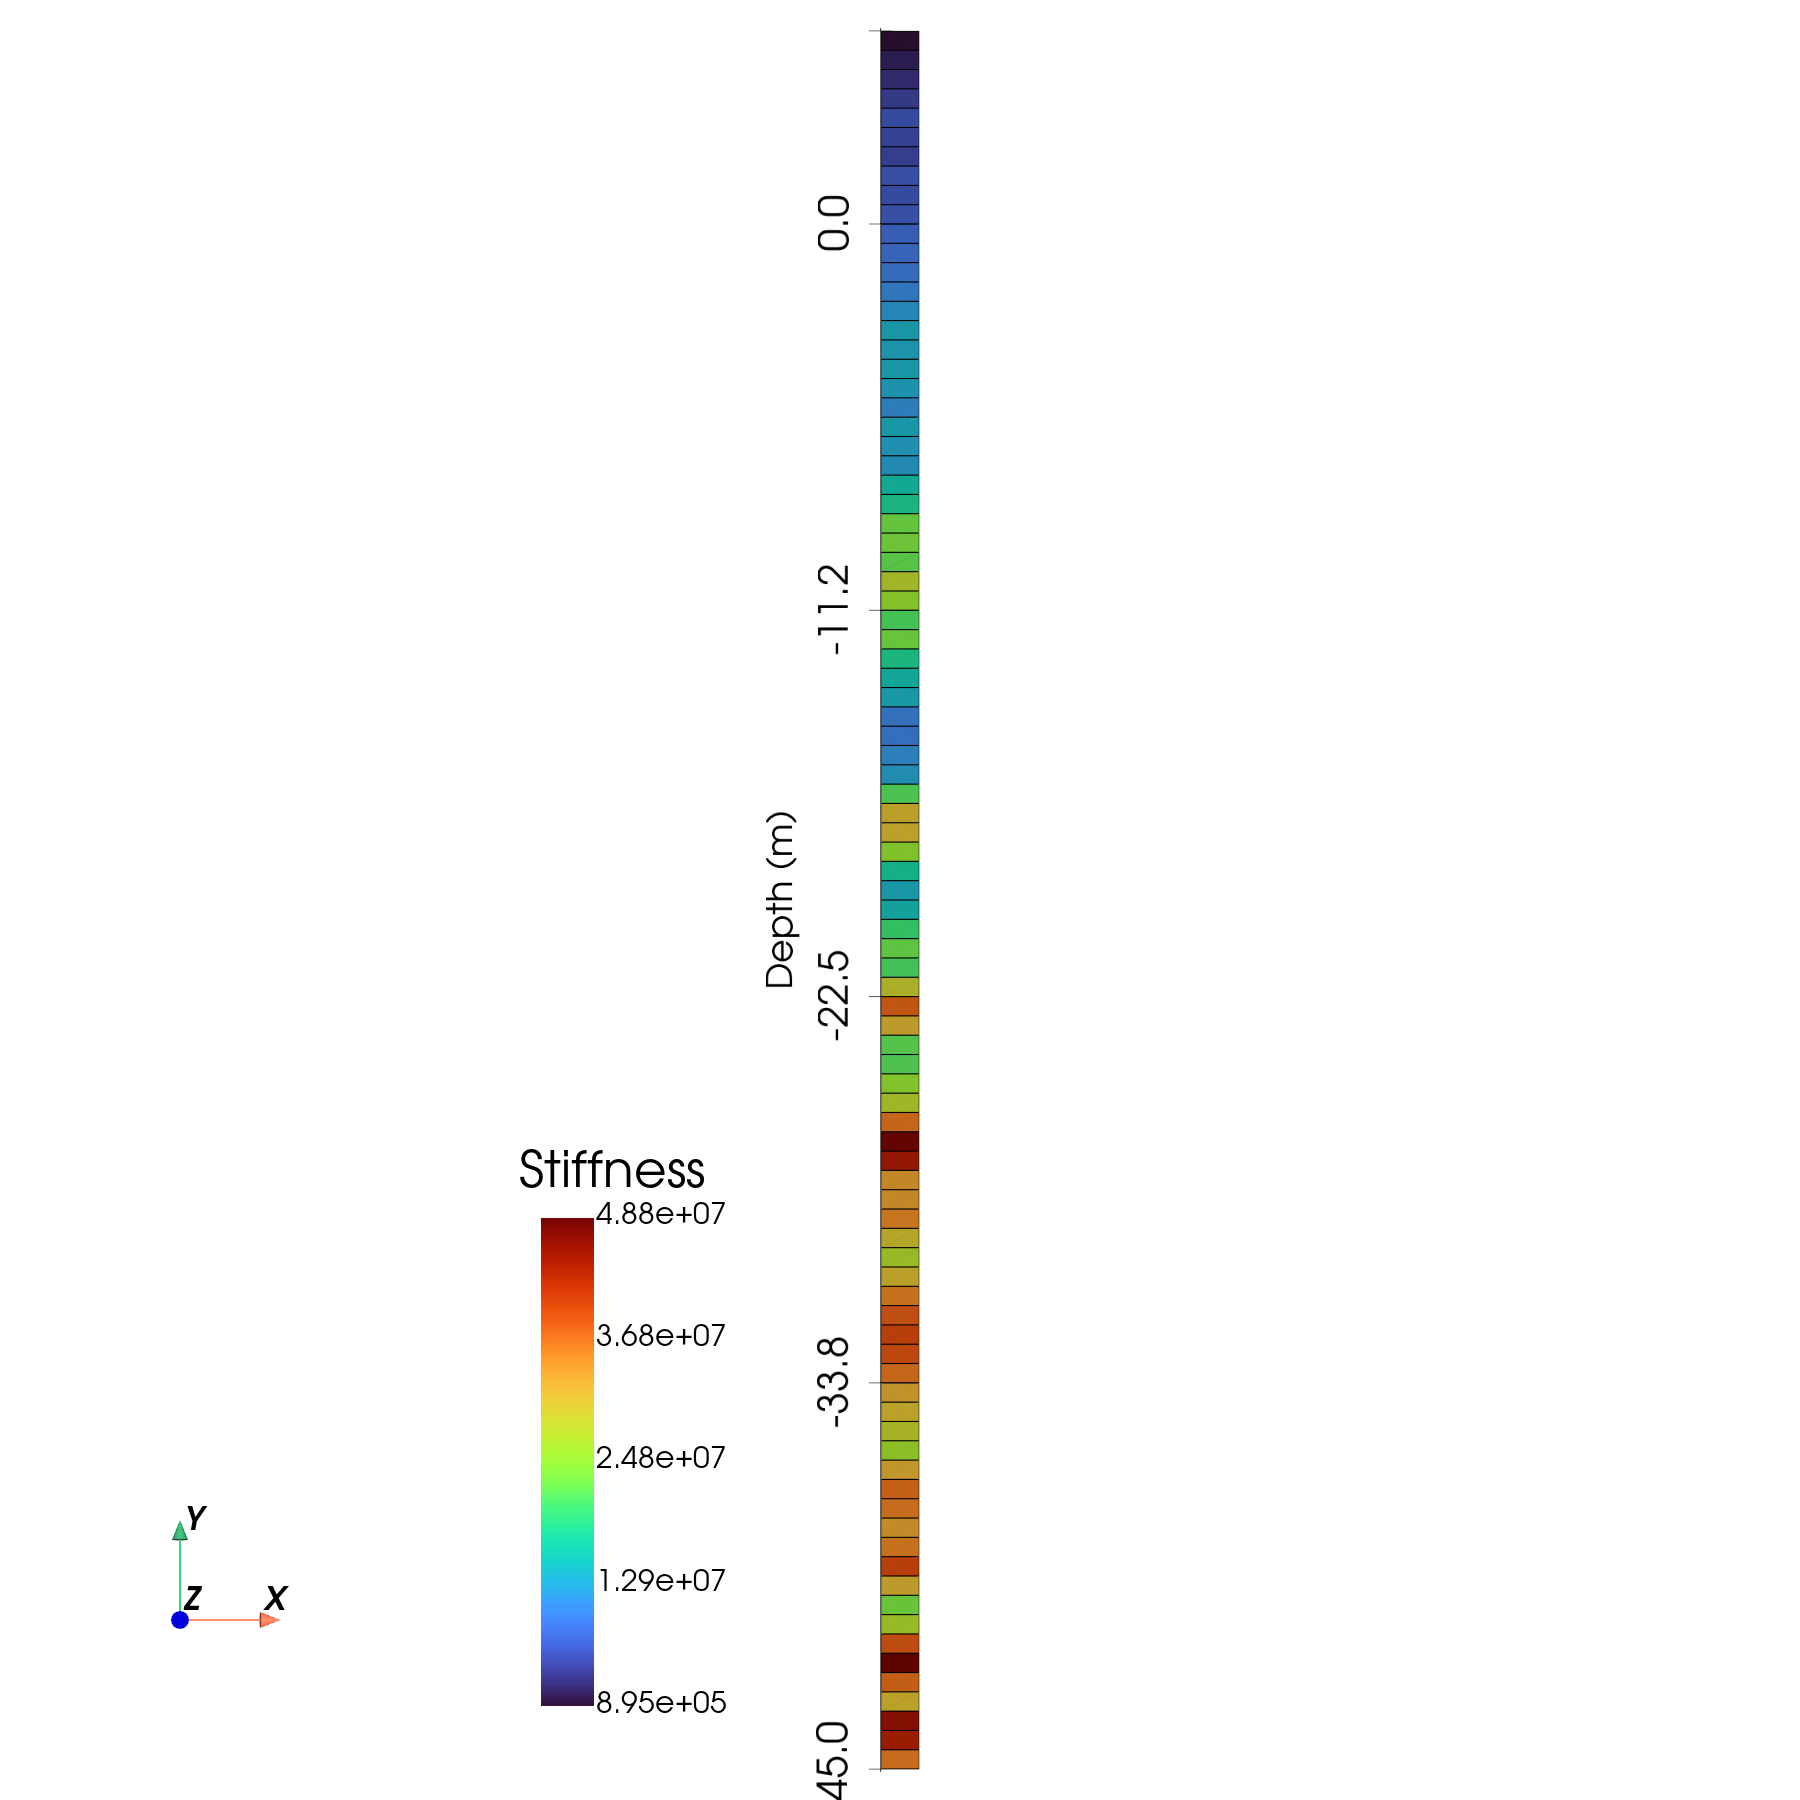

In [12]:
new_mesh = pv.read("domain_with_stiffness.vtu")

pl = pv.Plotter()

grid = pv.ImageData(spacing=(1, 1, 1))
sargs = dict(height=0.3, vertical=True, position_x=0.3, position_y=0.05, title_font_size=50,label_font_size=30)
pl.add_mesh(new_mesh,  scalars = "Stiffness", show_edges=True, cmap="turbo", scalar_bar_args=sargs)
if ey==1:    
    pl.view_xy()
pl.add_axes()
pl.window_size = [1800, 1800]


pl.show_grid(ytitle='Depth (m)', font_family ='arial', font_size=30, bold=False, 
            show_xaxis=False,
            show_yaxis=True,
            show_zaxis=False,  
            grid='back'   
            )

pl.show()


Here we draw a graph to visualize the change of stiffness parameter over depth. 

This is a graph taking the mid x-axis.

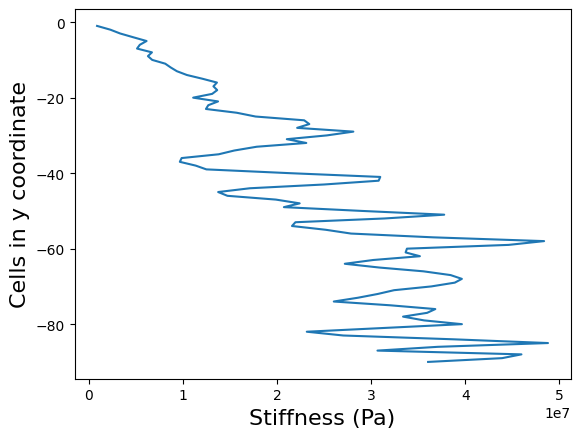

In [13]:
import matplotlib.pyplot as plt
import numpy as np

if ex == 1:
    xpoints = stiff_field[:]  
elif ey == 1:
    xpoints = stiff_field[ex // 2, :]  
else:
    xpoints = stiff_field[ex // 2, ey//2, :]  

ypoints = np.arange ( -ez, 0, 1)  #ez

plt.xlabel('Stiffness (Pa)', fontsize=16)
plt.ylabel('Cells in y coordinate', fontsize=16)

plt.plot(xpoints, ypoints)
plt.show()

This is a graph taking the mean of the x axis.

In [14]:
# xpoints = np.mean(stiff_field, axis=0)   # total_rf  to check detrended RF, stiffness to check trend
# #xpoints = np.flip(trend[1:])
# ypoints = np.arange ( -ez, 0, 1)

# plt.xlabel('Stiffness (Pa)', fontsize=16)
# plt.ylabel('Element index in z direction', fontsize=16)

# plt.plot(xpoints, ypoints)
# plt.show()

In [15]:
# Save the original Young's Modulus for later use

depth_upper = int(- (duration + initial_GWT)/resolution)
depth_lower = int(- (initial_GWT) /resolution)
stiff_field_extracted = stiff_field[::-1][depth_upper:depth_lower]
np.savetxt("./original_stiff_field.txt", stiff_field_extracted, fmt="%.4f")

In [17]:
os.chdir("..")